# LSTM

## Import libraries

In [1]:
import ccxt
from datetime import datetime
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Add,
    Dense,
    Dropout,
    Embedding,
    GlobalAveragePooling1D,
    Input,
    LayerNormalization,
    MultiHeadAttention,
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Huber
import matplotlib.pyplot as plt
import seaborn as sns

2026-04-11 14:35:08.302868: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Constants

In [2]:
TIMEFRAME_DICT = {
    "1m": 60 * 1000,
    "5m": 5 * 60 * 1000,
    "15m": 15 * 60 * 1000,
    "1h": 60 * 60 * 1000,
    "1d": 24 * 60 * 60 * 1000,
}

FREQ_DICT = {
    "1m": "T",
    "5m": "5T",
    "15m": "15T",
    "1h": "h",
    "1d": "D",
}

Y_OUTPUT_DICT = {
    "log_return_close": False,
    "bin_return_close": True,
    "bin_return_d2d_close": True,
}

In [3]:
CLIENT = ccxt.binance()
TICKER = "BTC/USDT"
END_DATE = CLIENT.parse8601("2026-03-31T20:00:00Z")
START_DATE = CLIENT.parse8601("2023-11-03T20:00:00Z")
TIMEFRAME = "1h"
LAGS_NUM = 240
TRAIN_TEST_SPLIT_RATIO = 0.7

TRANSFORMER_DIM = 64
NUM_HEADS = 4
HEAD_SIZE = TRANSFORMER_DIM // NUM_HEADS
FEED_FORWARD_DIM = 128
TRANSFORMER_BLOCKS = 2
MLP_UNITS = 64

EPOCHS_NUM = 100
BATCH_SIZE = 32
DROPOUT_RATE = 0.2
PATIENCE_NUM = 10
SCALER_BOOLEAN = False
OUTPUT_VALUE = 'bin_return_d2d_close'
BINARY_CLASSIFICATION = Y_OUTPUT_DICT[OUTPUT_VALUE]

## Fetching data

In [4]:
def fetch_data(client, ticker, start_date, end_date, timeframe):
    data = []
    while start_date < end_date:
        data = data + client.fetch_ohlcv(
            ticker,
            timeframe=timeframe,
            since=start_date,
            limit=1000,
        )
        start_date = data[-1][0] + TIMEFRAME_DICT[timeframe] - 1 # -1 to avoid duplicates
    return data

def preprocess_data(data):
    data = pd.DataFrame(
        data,
        columns=["Date", "Open", "High", "Low", "Close", "Volume"]
    )
    data["Date"] = pd.to_datetime(data["Date"], unit="ms")
    data = data.set_index("Date")
    return data

In [5]:
data = fetch_data(CLIENT, TICKER, START_DATE, END_DATE, TIMEFRAME)
data = preprocess_data(data)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2023-11-03 20:00:00,34530.71,34659.66,34485.65,34593.90,1046.24789
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035


### Verifying continuous of data

In [6]:
all_dates = pd.date_range(start=data.index.min(), end=data.index.max(), freq=FREQ_DICT[TIMEFRAME])
missing = all_dates.difference(data.index)
print(len(missing), missing)   # 0 => none missing dates

0 DatetimeIndex([], dtype='datetime64[ms]', freq='h')


## Processing data

In [7]:
data['log_return_close'] = np.log(data['Close'] / data['Close'].shift(1))
data['return_close'] = data['Close'] / data['Close'].shift(1) - 1
data['bin_return_close'] = (data['log_return_close'] > 0).astype(int)
data['bin_return_d2d_close'] = (data['log_return_close'] > data['log_return_close'].shift(1)).astype(int)

In [8]:
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,log_return_close,return_close,bin_return_close,bin_return_d2d_close
Date,,,,,,,,,
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031,0.000203,0.000203,1,0
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337,0.000786,0.000786,1,1
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032,0.002556,0.002560,1,1
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035,-0.000580,-0.000580,0,0
2023-11-04 01:00:00,34696.66,34786.68,34632.47,34768.15,724.86868,0.002059,0.002061,1,1


## Spliting data

In [9]:
X = data.drop(columns=['High', 'Low', 'Open', 'Close', 'Volume', 'bin_return_close', 'bin_return_d2d_close'])
y = data.drop(columns=['High', 'Low', 'Open', 'Close', 'Volume', 'log_return_close'])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1-TRAIN_TEST_SPLIT_RATIO, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, shuffle=False)
X_backtest, y_backtest = X_test.copy(), y_test.copy()

Overall probability of bin_return_d2d_close being the same as bin_return_close:
0.774


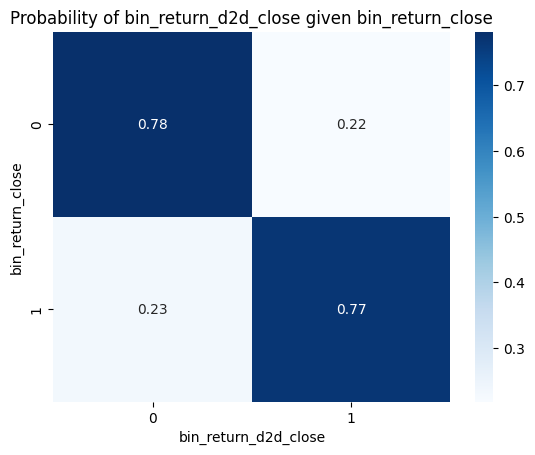

In [11]:
probs = pd.crosstab(
    y_train['bin_return_close'],
    y_train['bin_return_d2d_close'],
    normalize='index'
)
overall_prob = (y_train['bin_return_close'] == y_train['bin_return_d2d_close']).mean()
print("Overall probability of bin_return_d2d_close being the same as bin_return_close:\n{:.3f}".format(overall_prob))
sns.heatmap(probs, annot=True, fmt=".2f", cmap="Blues")
plt.title("Probability of bin_return_d2d_close given bin_return_close")
plt.xlabel("bin_return_d2d_close")
plt.ylabel("bin_return_close")
plt.show()

In [12]:
def generate_lags(X, y, lags_num, output_value, scaler_bool=False):
    X_values = X['log_return_close'].values
    y_values = y[output_value].values
    scaler = None
    if scaler_bool:
        scaler = StandardScaler()
        X_values = scaler.fit_transform(X_values.reshape(-1, 1)).flatten()
        if not BINARY_CLASSIFICATION:
            y_values = scaler.fit_transform(y_values.reshape(-1, 1)).flatten()
    X_return = []
    y_return = []
    for i in range(lags_num, len(X_values)):
        X_return.append(X_values[i-lags_num:i])
        y_return.append(y_values[i])
    X_return = np.array(X_return).reshape(-1, lags_num, 1)
    y_return = np.array(y_return).reshape(-1, 1)
    return X_return, y_return, scaler

In [13]:
X_train, y_train, scaler = generate_lags(X_train, y_train, LAGS_NUM, OUTPUT_VALUE, SCALER_BOOLEAN)
X_val, y_val, _ = generate_lags(X_val, y_val, LAGS_NUM, OUTPUT_VALUE, SCALER_BOOLEAN)
X_test, y_test, _ = generate_lags(X_test, y_test, LAGS_NUM, OUTPUT_VALUE, SCALER_BOOLEAN)

## Building and training model

In [14]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout_rate):
    attention_input = LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size,
        dropout=dropout_rate,
    )(attention_input, attention_input)
    attention_output = Dropout(dropout_rate)(attention_output)
    residual = Add()([inputs, attention_output])

    feed_forward_input = LayerNormalization(epsilon=1e-6)(residual)
    feed_forward_output = Dense(ff_dim, activation="relu")(feed_forward_input)
    feed_forward_output = Dropout(dropout_rate)(feed_forward_output)
    feed_forward_output = Dense(residual.shape[-1])(feed_forward_output)
    return Add()([residual, feed_forward_output])

def build_transformer_model(input_shape, binary_classification):
    inputs = Input(shape=input_shape)
    x = Dense(TRANSFORMER_DIM)(inputs)

    positions = tf.range(start=0, limit=input_shape[0], delta=1)
    position_embeddings = Embedding(
        input_dim=input_shape[0],
        output_dim=TRANSFORMER_DIM,
    )(positions)
    x = x + position_embeddings

    for _ in range(TRANSFORMER_BLOCKS):
        x = transformer_encoder(x, HEAD_SIZE, NUM_HEADS, FEED_FORWARD_DIM, DROPOUT_RATE)

    x = LayerNormalization(epsilon=1e-6)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(DROPOUT_RATE)(x)
    x = Dense(MLP_UNITS, activation="relu")(x)
    x = Dropout(DROPOUT_RATE)(x)

    if binary_classification:
        outputs = Dense(2, activation="softmax")(x)
        model = Model(inputs, outputs)
        model.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )
    else:
        outputs = Dense(1)(x)
        model = Model(inputs, outputs)
        model.compile(
            optimizer="adam",
            loss="mean_absolute_error",
            metrics=["mae"],
        )

    return model

model = build_transformer_model((X_train.shape[1], X_train.shape[2]), BINARY_CLASSIFICATION)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 240, 64)   │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 240, 64)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 240, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 240, 64)   │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 240, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 240, 64)   │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 240, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 240, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 240, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 240, 64)   │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 240, 64)   │          0 │ add_1[0][0],      │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 240, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 240, 64)   │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 240, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 240, 64)   │          0 │ add_2[0][0],      │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 240, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 240, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 240, 128)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 240, 64)   │      8,256 │ dropout_5[0][0] 

 Total params: 71,490 (279.26 KB)

 Trainable params: 71,490 (279.26 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
if BINARY_CLASSIFICATION:
    print("Binary classification")
    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS_NUM,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[EarlyStopping(monitor="val_accuracy", patience=PATIENCE_NUM, restore_best_weights=True)],
    )
else:
    print("Regression")
    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS_NUM,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[EarlyStopping(monitor="val_mae", patience=PATIENCE_NUM, restore_best_weights=True)],
    )

Binary classification
Epoch 1/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 318s 672ms/step - accuracy: 0.4961 - loss: 0.7048 - val_accuracy: 0.5039 - val_loss: 0.6932
Epoch 2/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 349s 759ms/step - accuracy: 0.4984 - loss: 0.6939 - val_accuracy: 0.5039 - val_loss: 0.6931
Epoch 3/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 1274s 761ms/step - accuracy: 0.4985 - loss: 0.6938 - val_accuracy: 0.5039 - val_loss: 0.6931
Epoch 4/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 335s 728ms/step - accuracy: 0.4967 - loss: 0.6936 - val_accuracy: 0.4961 - val_loss: 0.6932
Epoch 5/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 2451s 5s/step - accuracy: 0.5038 - loss: 0.6933 - val_accuracy: 0.4961 - val_loss: 0.6937
Epoch 6/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 2707s 6s/step - accuracy: 0.5007 - loss: 0.6933 - val_accuracy: 0.5039 - val_loss: 0.6934
Epoch 7/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 350s 761ms/step - accuracy: 0.5056 - loss: 0.6933 - val_accuracy: 0.4961 - val_loss: 0.6938
Epoch 8/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 331s 720m

## Verifying model

In [16]:
y_pred = model.predict(X_test)
if BINARY_CLASSIFICATION:
    y_pred = np.argmax(y_pred, axis=1)
else:
    if SCALER_BOOLEAN:
        y_pred = scaler.inverse_transform(y_pred.flatten().reshape(-1, 1)).flatten()
        y_test = scaler.inverse_transform(y_test.flatten().reshape(-1, 1)).flatten()

93/93 ━━━━━━━━━━━━━━━━━━━━ 33s 353ms/step


In [17]:
print(y_test.flatten()[:10])
print(y_pred.flatten()[:10])

[1 1 0 1 1 1 0 0 1 0]
[0 0 0 0 0 0 0 0 0 0]


In [18]:
if BINARY_CLASSIFICATION:
    print(classification_report(y_test.flatten(), y_pred))
else:
    print("Regression metrics would be printed here.")
    Directional_accuracy = np.mean((y_pred > 0) == (y_test.flatten() > 0))
    print(f"Directional accuracy: {Directional_accuracy:.4f}")

              precision    recall  f1-score   support

           0       0.51      1.00      0.67      1505
           1       0.00      0.00      0.00      1458

    accuracy                           0.51      2963
   macro avg       0.25      0.50      0.34      2963
weighted avg       0.26      0.51      0.34      2963



/Users/mikolaj/Desktop/STUDIA/CDV STOPIEŃ II/MAGISTERKA/master-thesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mikolaj/Desktop/STUDIA/CDV STOPIEŃ II/MAGISTERKA/master-thesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mikolaj/Desktop/STUDIA/CDV STOPIEŃ II/MAGISTERKA/master-thesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels

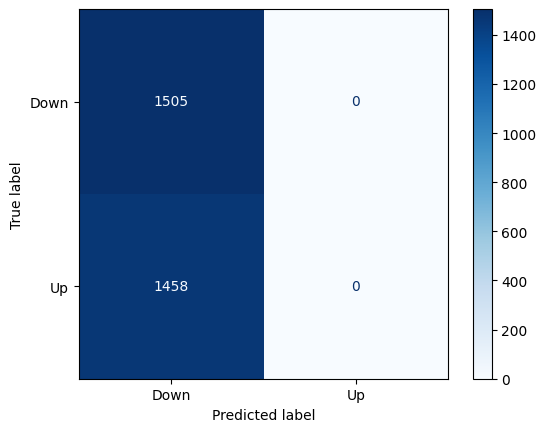

In [19]:
if BINARY_CLASSIFICATION:
    ConfusionMatrixDisplay.from_predictions(y_test.flatten(), y_pred, cmap='Blues', display_labels=["Down", "Up"])
else:
    print("Confusion matrix is not applicable for regression.")
    plt.figure(figsize=(12, 8))
    plt.plot(y_test.flatten(), label='True')
    plt.plot(y_pred.flatten()/10, label='Predicted')
    plt.legend()
    plt.show()

In [20]:
# Coverage model pred with bin_return_close
prob_coverage = overall_prob * classification_report(y_test.flatten(), y_pred, output_dict=True)['accuracy']
print("Coverage model accuracy based on bin_return_close:\n{:.3f}".format(prob_coverage))

Coverage model accuracy based on bin_return_close:
0.393


/Users/mikolaj/Desktop/STUDIA/CDV STOPIEŃ II/MAGISTERKA/master-thesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mikolaj/Desktop/STUDIA/CDV STOPIEŃ II/MAGISTERKA/master-thesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mikolaj/Desktop/STUDIA/CDV STOPIEŃ II/MAGISTERKA/master-thesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels

## Backtesting model

Final cash: 1110.00
Total return: 11.00%


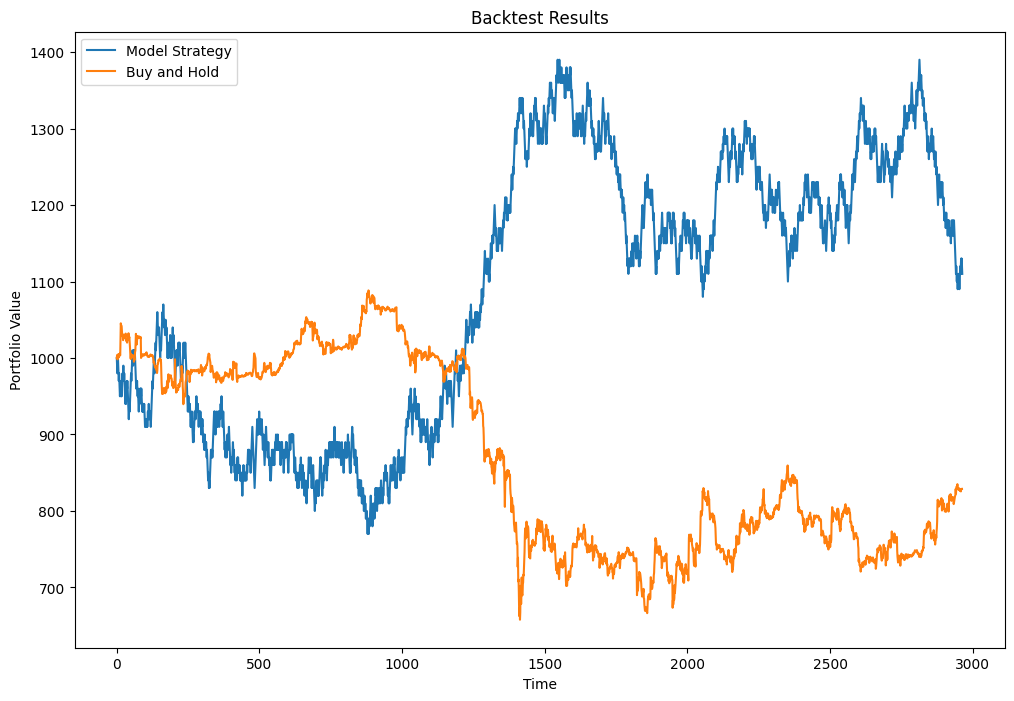

In [21]:
y_return = X_backtest['return_close'].values[-len(y_pred):]
start_cash = 1000
cash = start_cash
movement_list = [cash]
for i in range(len(y_pred)):
    if y_pred[i] == 1:
        cash += 10 if y_return[i] > 0 else -10  # Assuming we buy the asset when predicting an up movement
    else:
        cash += 10 if y_return[i] < 0 else -10  # Assuming we short the asset when predicting a down movement
    movement_list.append(cash)
print(f"Final cash: {cash:.2f}")
print(f"Total return: {(cash - start_cash) / start_cash * 100:.2f}%")
plt.figure(figsize=(12, 8))
plt.plot(movement_list, label='Model Strategy')
plt.plot(movement_list[0] * (1 + y_return.cumsum()), label='Buy and Hold')
plt.xlabel('Time')
plt.ylabel('Portfolio Value')
plt.title('Backtest Results')
plt.legend()
plt.show()
